<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Dailychallenge_J2_W4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- First 5 Rows of the Dataset ---
   Exam_1_Score  Exam_2_Score  Admitted
0     34.623660     78.024693         0
1     30.286711     43.894998         0
2     35.847409     72.902198         0
3     60.182599     86.308552         1
4     79.032736     75.344376         1


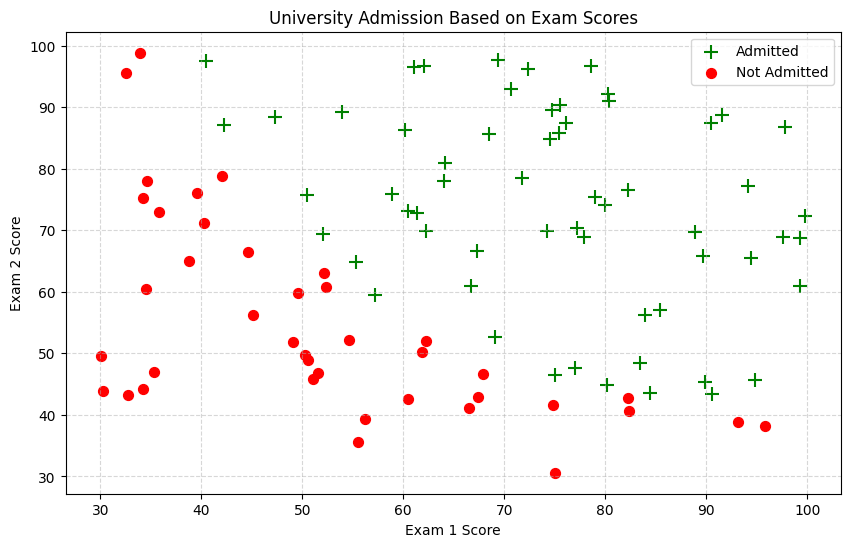

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the dataset (replace with your file path or URL)
# The dataset has columns: Exam1, Exam2, Admitted
url = "https://raw.githubusercontent.com/kaleko/CourseraML/master/ex2/data/ex2data1.txt"
columns = ['Exam_1_Score', 'Exam_2_Score', 'Admitted']
df = pd.read_csv(url, names=columns)

# Examine the first few rows
print("--- First 5 Rows of the Dataset ---")
print(df.head())

# 2. Visualize the data points using a scatter plot
plt.figure(figsize=(10, 6))

# Filter rows based on admission status
admitted = df[df['Admitted'] == 1]
not_admitted = df[df['Admitted'] == 0]

# Plot data points
plt.scatter(admitted['Exam_1_Score'], admitted['Exam_2_Score'],
            color='green', marker='+', s=100, label='Admitted')
plt.scatter(not_admitted['Exam_1_Score'], not_admitted['Exam_2_Score'],
            color='red', marker='o', s=50, label='Not Admitted')

# Labeling the chart
plt.title('University Admission Based on Exam Scores')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [3]:
# Separate features (X) and target variable (y)
X = df[['Exam_1_Score', 'Exam_2_Score']].values
y = df['Admitted'].values

# Initialize the Scikit-Learn Logistic Regression model
# We set penalty=None to replicate exact baseline logistic regression without regularization
model = LogisticRegression(penalty=None)

# Train (fit) the model on the entire dataset
model.fit(X, y)

# Extract learned parameters
intercept = model.intercept_[0]
coefficients = model.coef_[0]

print("--- Model Parameters Found ---")
print(f"Intercept (b): {intercept:.4f}")
print(f"Coefficient for Exam 1 (w1): {coefficients[0]:.4f}")
print(f"Coefficient for Exam 2 (w2): {coefficients[1]:.4f}")


--- Model Parameters Found ---
Intercept (b): -25.1614
Coefficient for Exam 1 (w1): 0.2062
Coefficient for Exam 2 (w2): 0.2015


In [4]:
# Make predictions on the dataset
y_pred = model.predict(X)

# Calculate model accuracy
accuracy = accuracy_score(y, y_pred)

print("--- Prediction Performance ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%")


--- Prediction Performance ---
Model Accuracy: 89.00%


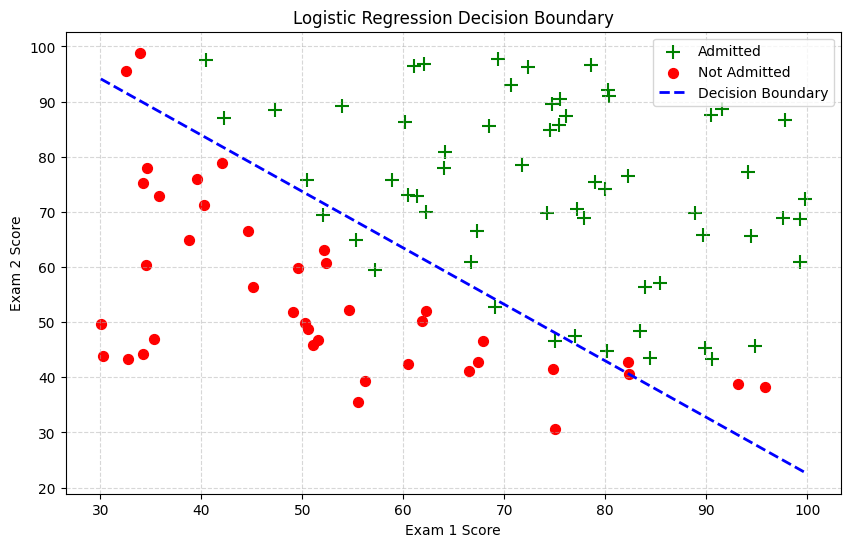


--- Detailed Classification Metrics ---
[[34  6]
 [ 5 55]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86        40
           1       0.90      0.92      0.91        60

    accuracy                           0.89       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



In [5]:
# Plot the dataset again
plt.figure(figsize=(10, 6))
plt.scatter(admitted['Exam_1_Score'], admitted['Exam_2_Score'], color='green', marker='+', s=100, label='Admitted')
plt.scatter(not_admitted['Exam_1_Score'], not_admitted['Exam_2_Score'], color='red', marker='o', s=50, label='Not Admitted')

# Calculate the Decision Boundary line
# Formula: Intercept + (w1 * x1) + (w2 * x2) = 0  -> Solve for x2:
x1_values = np.array([df['Exam_1_Score'].min(), df['Exam_1_Score'].max()])
x2_values = -(intercept + coefficients[0] * x1_values) / coefficients[1]

# Plot decision boundary line
plt.plot(x1_values, x2_values, color='blue', linestyle='--', linewidth=2, label='Decision Boundary')

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Additional deep-dive analytics
print("\n--- Detailed Classification Metrics ---")
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))
